# Norman 2019 — Main Figure

Runs SHERLOCK (`l0_lambda=25, rank=6, synergy=True`) `N_RUNS` times on the held-out Norman split,
selects the best model by held-out combo ATE, and assembles a four-panel journal figure:

| Panel | Content |
|---|---|
| **(a)** | Counterfactual ATE across N runs — reproducibility & OOD generalisation |
| **(b)** | Single-perturbation latent UMAP (best model) |
| **(c)** | Parent-coefficient scatter (c₁ vs c₂) coloured by Norman GT class |
| **(d)** | GI classification AUC-ROC per class — SHERLOCK vs GEARS |

The notebook saves every intermediate result to `results/norman_figure/` and the final
composite figure to `results/norman_figure/main_figure.pdf`.

In [1]:
import os, sys, math, random, textwrap
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, bootstrap
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import torch

sys.path.append('../../..')
import sherlock as slk
from sherlock.tools._models import classify_gi

# ── Journal figure style ────────────────────────────────────────────────
RC = {
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':             8,
    'axes.labelsize':        8,
    'axes.titlesize':        9,
    'xtick.labelsize':       7,
    'ytick.labelsize':       7,
    'legend.fontsize':       6,
    'legend.title_fontsize': 7,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.75,
    'xtick.major.width':     0.75,
    'ytick.major.width':     0.75,
    'xtick.major.size':      3,
    'ytick.major.size':      3,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'pdf.fonttype':          42,
    'ps.fonttype':           42,
    'svg.fonttype': 'none',
}
mpl.rcParams.update(RC)

PPI = 96  # Figma/CSS px-per-inch — matches how pt-labeled SVGs get imported

# ── Colour palette ─────────────────────────────────────────────────────
CLR_SHERLOCK = '#2166ac'
CLR_GEARS    = '#d73027'

# Keys match the exact strings in genetic_interactions.csv
PALETTE_GI = {
    'approximately additive':         '#4DAF4A',  # green
    'epistasis':                      '#FF7F00',  # orange
    'neomorphic':                     '#984EA3',  # purple
    'potentiation':                   '#F781BF',  # pink
    'redundant':                      '#A65628',  # brown
    'suppression':                    '#E41A1C',  # red
    'synergy (dissimilar phenotype)': '#377EB8',  # blue
    'synergy (similar phenotype)':    '#6BAED6',  # light blue
}

def _add_umap_axis_indicator(ax, x_label='UMAP1', y_label='UMAP2', length=0.15,
                              lw=1.0, color='0.15', fontsize=None):
    """Small L-shaped corner axis indicator (scanpy/Seurat style) — two short
    arrows from the bottom-left corner instead of full tick-labelled spines,
    used on UMAP panels where absolute coordinates are meaningless."""
    if fontsize is None:
        fontsize = mpl.rcParams['axes.labelsize']
    ax.annotate('', xy=(length, 0), xytext=(0, 0),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                                 shrinkA=0, shrinkB=0))
    ax.annotate('', xy=(0, length), xytext=(0, 0),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                                 shrinkA=0, shrinkB=0))
    ax.text(length / 2, -0.03, x_label, transform=ax.transAxes, fontsize=fontsize,
            ha='center', va='top', color=color)
    ax.text(-0.03, length / 2, y_label, transform=ax.transAxes, fontsize=fontsize,
            ha='right', va='center', color=color, rotation=90)


# ── Constants ──────────────────────────────────────────────────────────
N_RUNS    = 5
SEED_BASE = 0
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT_DIR   = Path('./results/norman_figure')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}  |  N_RUNS: {N_RUNS}  |  Output: {OUT_DIR}')

Device: cuda  |  N_RUNS: 5  |  Output: results/norman_figure


## 1. Load and preprocess Norman 2019

In [2]:
data = sc.read_h5ad('../../datasets/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()

slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f'Cells: {data.n_obs}  |  Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}  |  Combo perts: {len(combo_perts)}')

Cells: 111255  |  Genes: 19018
Single perts: 105  |  Combo perts: 131


In [3]:
# Gene filtering: keep genes with mean count > 0.5 UMI or that are pert targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

mean_expr = np.array(data.X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

print(f'Kept {data.n_vars} genes  '
      f'({expr_mask[keep_mask].sum()} expr + '
      f'{(pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum()} pert-only)')

Kept 3270 genes  (3190 expr + 80 pert-only)


In [4]:
# Observed treatment effects (log2-CPM vs NTC baseline)
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f'treat_effect: {te.n_obs} perturbations × {te.n_vars} genes')

100%|██████████| 236/236 [00:04<00:00, 51.67it/s]

treat_effect: 236 perturbations × 3270 genes


## 2. Train/val split — 20% of each Norman GT class held out

In [5]:
def canon_pair(s):
    s = str(s)
    if '+' not in s:
        return s
    a, b = s.split('+', 1)
    return '+'.join(sorted([a.strip(), b.strip()]))

random.seed(42)
gi_labels = pd.read_csv('./genetic_interactions.csv')
gi_labels['combination'] = gi_labels['combination'].apply(canon_pair)
gi_labels['genetic_interaction'] = gi_labels['genetic_interaction'].str.strip()

val_combos = set()
for cls, grp in gi_labels.groupby('genetic_interaction'):
    n_val = math.ceil(0.2 * len(grp))
    val_combos.update(random.sample(list(grp['combination']), n_val))

val_mask   = data.obs[p_key].apply(lambda p: ('+' in str(p)) and (canon_pair(p) in val_combos))
data_train = data[~val_mask].copy()

print(f'Total cells: {data.n_obs}  |  Training: {data_train.n_obs}')
print(f'GT pairs: {len(gi_labels)}  |  Held-out val combos: {len(val_combos)}')

Total cells: 111255  |  Training: 104626
GT pairs: 88  |  Held-out val combos: 22


## 3. Multi-run training

Trains SHERLOCK `N_RUNS` times with identical settings. After each run, computes ATE on
the full data (including held-out combos). The best run by held-out combo ATE is used for
UMAP, synergy analysis, and GI classification.

In [6]:
def _ate_r(pred_df, obs_df, idx):
    idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
    if len(idx) < 2:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return float(pearsonr(x[v], y[v])[0]) if v.sum() > 2 else float('nan')


def _effect_size_r(pred_df, obs_df):
    common = pred_df.index.intersection(obs_df.index)
    if len(common) < 3:
        return float('nan')
    p_norms = pred_df.loc[common].apply(np.linalg.norm, axis=1).values
    o_norms = obs_df.loc[common].apply(np.linalg.norm, axis=1).values
    v = np.isfinite(p_norms) & np.isfinite(o_norms)
    return float(pearsonr(p_norms[v], o_norms[v])[0]) if v.sum() > 2 else float('nan')


def _w_coact_matrix(W, threshold=0.5):
    """(P, P) cosine-normalized perturbation co-activation matrix. Invariant
    to permutation of the K gate dimensions, so it can be compared directly
    across independently trained runs (unlike the raw W)."""
    W_bin = (W > threshold).astype(float)
    dot   = W_bin @ W_bin.T
    norms = np.sqrt(np.diag(dot))
    denom = np.outer(norms, norms) + 1e-8
    return dot / denom


def _flat_triu(M):
    idx = np.triu_indices(M.shape[0], k=1)
    return M[idx]


def _loo_spearman_df(mats_by_run, metric_name):
    """Spearman r between each run's (P, P) matrix and the elementwise mean of
    every OTHER run's matrix (leave-one-out) — one row per run (n total).
    Unlike the C(n, 2) all-pairs comparisons, these n points each depend on a
    distinct held-out run, so they behave like an i.i.d. sample for
    bootstrapping instead of n(n-1)/2 non-independent pairs drawn from only
    n underlying runs."""
    rows = []
    keys = sorted(mats_by_run)
    for k in keys:
        others = [mats_by_run[j] for j in keys if j != k]
        if not others:
            continue
        mean_other = np.mean(others, axis=0)
        vi, vj = _flat_triu(mats_by_run[k]), _flat_triu(mean_other)
        valid  = np.isfinite(vi) & np.isfinite(vj)
        r = float(spearmanr(vi[valid], vj[valid])[0]) if valid.sum() > 2 else float('nan')
        rows.append({'metric': metric_name, 'run': k, 'r': r})
    return pd.DataFrame(rows)


def _compute_ate_metrics(model, data, val_combos):
    """Compute all ATE breakdown metrics for a model on full data."""
    ate  = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'],
    )
    pred = ate['predicted_df']
    obs  = ate['observed_df']
    singles = [p for p in pred.index if '+' not in str(p)]
    combos  = [p for p in pred.index if '+' in str(p) and canon_pair(p) not in val_combos]
    held    = [p for p in pred.index if canon_pair(p) in val_combos]
    return ate, pred, obs, {
        'ate_all':    ate['corr'],
        'ate_single': _ate_r(pred, obs, singles),
        'ate_combo':  _ate_r(pred, obs, combos),
        'ate_held':   _ate_r(pred, obs, held),
    }


def _cache_fresh(cache_path, *source_paths):
    """True if cache_path exists and is at least as new as every path in
    source_paths (files, or directories checked recursively). Retraining a
    model should invalidate every cache derived from it; comparing mtimes
    lets that happen automatically instead of a cache silently outliving the
    checkpoint(s) it was computed from."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return False
    cache_mtime = cache_path.stat().st_mtime
    for src in source_paths:
        src = Path(src)
        if not src.exists():
            return False
        if src.is_dir():
            sub_paths = list(src.rglob('*'))
            if not sub_paths:
                continue
            src_mtime = max(p.stat().st_mtime for p in sub_paths)
        else:
            src_mtime = src.stat().st_mtime
        if src_mtime > cache_mtime:
            return False
    return True


# ── Paths ──────────────────────────────────────────────────────────────
MODELS_DIR        = OUT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUN_METRICS_PATH  = OUT_DIR / 'run_metrics.csv'
RUN_MATRICES_PATH = OUT_DIR / 'run_matrices.npz'
PAIRWISE_PATH     = OUT_DIR / 'pairwise_repro.csv'
checkpoints       = {i + 1: MODELS_DIR / f'run_{i + 1}.pth' for i in range(N_RUNS)}

if RUN_METRICS_PATH.exists():
    _saved = pd.read_csv(RUN_METRICS_PATH)
    existing_metrics = {int(r['run']): r for r in _saved.to_dict('records')}
else:
    existing_metrics = {}

if RUN_MATRICES_PATH.exists():
    _saved_mats  = np.load(RUN_MATRICES_PATH)
    rho_by_run   = {int(k.split('_')[-1]): _saved_mats[k] for k in _saved_mats.files if k.startswith('rho_corr_')}
    wcoact_by_run = {int(k.split('_')[-1]): _saved_mats[k] for k in _saved_mats.files if k.startswith('wcoact_')}
else:
    rho_by_run, wcoact_by_run = {}, {}

# ── Training / loading loop ────────────────────────────────────────────
for run_num in range(1, N_RUNS + 1):
    ckpt_path    = checkpoints[run_num]
    already_done = (run_num in existing_metrics) and ckpt_path.exists()

    if already_done:
        m = existing_metrics[run_num]
        print(f'Run {run_num}: loaded  '
              f"ate_all={m['ate_all']:.4f}  ate_single={m.get('ate_single', float('nan')):.4f}  "
              f"ate_combo={m.get('ate_combo', float('nan')):.4f}  ate_held={m['ate_held']:.4f}")
        if run_num not in rho_by_run or run_num not in wcoact_by_run:
            _model = slk.tl.load_results(ckpt_path)
            slk.tl.eval_single(_model, data_train, obsm_key='_z_tmp', uns_key='_tmp', device=DEVICE)
            _tmp = data_train.uns['_tmp']
            if _tmp.get('rho_corr') is not None:
                rho_by_run[run_num] = np.asarray(_tmp['rho_corr'], dtype=float)
            if _tmp.get('W') is not None:
                wcoact_by_run[run_num] = _w_coact_matrix(np.asarray(_tmp['W'], dtype=float))
        continue

    print(f'\n── Training run {run_num}/{N_RUNS} ──────────────────────────')
    out = slk.tl.run_single(
        data_train,
        model='vae',
        l0_lambda=20, #25
        rank=6,
        combinatorial=True,
        synergy=True,
        synergy_rank=6,
        shuffle=True,
        num_workers=0,
        device=DEVICE,
        num_epochs=500,
        validate_every=50,
        patience=15,
        n_epochs_l0_warmup=200,
        seed=SEED_BASE + run_num - 1,
        debug=False,
    )
    slk.tl.save_results(out, ckpt_path)

    model = out['model']
    _, pred, obs, ate_metrics = _compute_ate_metrics(model, data, val_combos)

    slk.tl.eval_single(model, data_train, obsm_key='_z_tmp', uns_key='_tmp', device=DEVICE)
    tmp   = data_train.uns['_tmp']
    W_mat = tmp.get('W')
    if tmp.get('rho_corr') is not None:
        rho_by_run[run_num] = np.asarray(tmp['rho_corr'], dtype=float)
    if W_mat is not None:
        wcoact_by_run[run_num] = _w_coact_matrix(np.asarray(W_mat, dtype=float))

    m = {
        'run':           run_num,
        **ate_metrics,
        'effect_size_r': _effect_size_r(pred, obs),
    }
    existing_metrics[run_num] = m
    pd.DataFrame(list(existing_metrics.values())).sort_values('run').to_csv(
        RUN_METRICS_PATH, index=False,
    )
    print(f"  ate_all={m['ate_all']:.4f}  ate_single={m['ate_single']:.4f}  "
          f"ate_combo={m['ate_combo']:.4f}  ate_held={m['ate_held']:.4f}")

np.savez(
    RUN_MATRICES_PATH,
    **{f'rho_corr_{k}': v for k, v in rho_by_run.items()},
    **{f'wcoact_{k}':   v for k, v in wcoact_by_run.items()},
)

# ── Cross-run reproducibility (rho_corr, W coactivation) ────────────────
# For each run, Spearman r between flattened upper-triangles of its rho_corr
# (learned perturbation covariance) / W-coactivation matrix and the mean of
# the OTHER runs' matrices (leave-one-out). This gives n independent points
# (one per run) instead of the C(n, 2) all-pairs comparisons, which reuse
# each run across multiple pairs and so are not i.i.d. even though there are
# more of them. effect_size_r stays a per-run metric since it measures
# within-run predictive accuracy, not cross-run reproducibility.
runs_df = pd.read_csv(RUN_METRICS_PATH)

pairwise_df = pd.concat([
    _loo_spearman_df(rho_by_run, 'rho_corr_r'),
    _loo_spearman_df(wcoact_by_run, 'w_coact_r'),
], ignore_index=True)
pairwise_df.to_csv(PAIRWISE_PATH, index=False)

for _metric, _grp in pairwise_df.groupby('metric'):
    _vals = _grp['r'].dropna().values
    if len(_vals) >= 3:
        _boot = bootstrap((_vals,), np.mean, confidence_level=0.95,
                           method='percentile', random_state=0)
        print(f'{_metric}: mean r = {_vals.mean():.4f}  '
              f'95% CI [{_boot.confidence_interval.low:.4f}, {_boot.confidence_interval.high:.4f}]  '
              f'(n_runs={len(_vals)})')
    elif len(_vals) == 1:
        print(f'{_metric}: r = {_vals[0]:.4f}  '
              f'(only 1 run — need >=3 runs for a bootstrap CI)')
    else:
        print(f'{_metric}: no valid runs.')

# ── Select and load best model ─────────────────────────────────────────
runs_df  = runs_df[runs_df['run'].map(lambda r: checkpoints.get(int(r), Path()).exists())]
best_run = int(runs_df.loc[runs_df['ate_held'].idxmax(), 'run'])
best_ate = float(runs_df['ate_held'].max())

print(f'\nBest run: {best_run}  (ate_held = {best_ate:.4f})')
best_model = slk.tl.load_results(checkpoints[best_run])
runs_df

Run 1: loaded  ate_all=0.7125  ate_single=0.5855  ate_combo=0.7615  ate_held=0.7287
Run 2: loaded  ate_all=0.6653  ate_single=0.4569  ate_combo=0.7364  ate_held=0.7073
Run 3: loaded  ate_all=0.7435  ate_single=0.6271  ate_combo=0.7893  ate_held=0.7521
Run 4: loaded  ate_all=0.6982  ate_single=0.5513  ate_combo=0.7532  ate_held=0.7141
Run 5: loaded  ate_all=0.6784  ate_single=0.5224  ate_combo=0.7342  ate_held=0.7145
rho_corr_r: mean r = 0.6606  95% CI [0.6336, 0.6908]  (n_runs=5)
w_coact_r: mean r = 0.9191  95% CI [0.9123, 0.9259]  (n_runs=5)

Best run: 3  (ate_held = 0.7521)


,run,ate_all,ate_single,ate_combo,ate_held,effect_size_r
0,1,0.712546,0.585499,0.761517,0.728717,0.783703
1,2,0.665266,0.456864,0.736384,0.707254,0.698456
2,3,0.743466,0.627053,0.789259,0.752105,0.802412
3,4,0.698181,0.551273,0.753197,0.714110,0.721916
4,5,0.678420,0.522366,0.734154,0.714480,0.662733


## 3b. Other benchmark methods (cVAE, sVAE, contrastiveVI, scgen)

Same hyperparameters/model kwargs as `benchmarking_combinatorial.ipynb`'s `METHODS` list, trained
on the same held-out combinatorial split (`data_train`/`val_combos`). `sherlock_synergy` isn't
listed separately since the SHERLOCK run above already trains with `synergy=True`. Each
method/run is checkpointed independently (as in `benchmarking.ipynb`), so a re-executed notebook
reloads finished runs instead of retraining.

**Combos are atomic labels, not compositional.** Unlike SHERLOCK (`combinatorial=True`, which
splits `"A+B"` into components and sums their learned shifts — the mechanism that lets it
extrapolate to held-out combos at all), these baselines are run with `combinatorial=False`:
`"A+B"` gets its own independent embedding, exactly like a third, unrelated perturbation — no
sharing with `"A"` or `"B"`. That means a combo the model never saw in training has *no* learned
representation whatsoever, so held-out ATE is undefined for these methods by construction (not
just poor). Evaluation therefore uses `data_train` (not the full `data`) as the ATE prediction
input: `predict_counterfactual_effects` rebuilds its own perturbation index internally from
whatever `adata` it's given, so evaluating on the full `data` here would silently reintroduce the
held-out combos into that index and misalign every perturbation sorted after them relative to the
model's trained embedding table — evaluating on `data_train` keeps the eval-time and train-time
indices identical and simply leaves held-out combos absent (→ `ate_held` = NaN via the existing
`_ate_r` NaN-on-empty-index handling), correctly and safely. In Panel A below, that means the
`ATE (held-out)` box is populated by SHERLOCK only.

In [7]:
# ── Other benchmark methods (cVAE, sVAE, contrastiveVI, scgen) ────────────
OTHER_METHODS = [
    ('cvae',          'cVAE',          {'combinatorial': False}),
    ('svae',          'sVAE',          {'sparse_mask_penalty': 10.0, 'combinatorial': False}),
    ('contrastivevi', 'contrastiveVI', {'combinatorial': False}),
    ('scgen',         'scgen',         {}),
]
OTHER_EPOCHS         = 200
OTHER_BATCH_SIZE     = 4096
OTHER_LATENT_DIM     = 16
OTHER_PATIENCE       = 20
OTHER_VALIDATE_EVERY = 50

BENCH_MODELS_DIR   = OUT_DIR / 'benchmark_models'
BENCH_MODELS_DIR.mkdir(parents=True, exist_ok=True)
BENCH_METRICS_PATH = OUT_DIR / 'benchmark_run_metrics.csv'

if BENCH_METRICS_PATH.exists():
    bench_records = pd.read_csv(BENCH_METRICS_PATH).to_dict('records')
else:
    bench_records = []
bench_done = {(r['method'], int(r['run'])) for r in bench_records}

for model_key, display_name, extra_kwargs in OTHER_METHODS:
    method_dir = BENCH_MODELS_DIR / display_name
    method_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs, {OTHER_EPOCHS} epochs)\n{'='*60}")

    for run_num in range(1, N_RUNS + 1):
        if (display_name, run_num) in bench_done:
            print(f'  run {run_num}/{N_RUNS}: metrics already cached, skipping.')
            continue

        ckpt_path = method_dir / f'run_{run_num}.pth'
        if ckpt_path.exists():
            print(f'  run {run_num}/{N_RUNS}: loading checkpoint {ckpt_path}')
            model = slk.tl.load_results(ckpt_path)
        else:
            print(f'  run {run_num}/{N_RUNS}: training...')
            out = slk.tl.run(
                data_train,
                model=model_key,
                batch_size=OTHER_BATCH_SIZE,
                num_epochs=OTHER_EPOCHS,
                device=DEVICE,
                latent_dim=OTHER_LATENT_DIM,
                patience=OTHER_PATIENCE,
                validate_every=OTHER_VALIDATE_EVERY,
                seed=SEED_BASE + run_num - 1,
                **extra_kwargs,
            )
            model = out['model']
            slk.tl.save_results(out, ckpt_path)

        # data_train (not data) — see markdown above: these models treat every
        # combo as an atomic label, so evaluating on data_train keeps the
        # eval-time perturbation index identical to the trained one and
        # leaves held-out combos correctly absent (ate_held -> NaN) instead
        # of silently misaligning indices for everything else.
        _, _, _, ate_metrics = _compute_ate_metrics(model, data_train, val_combos)
        record = {'method': display_name, 'run': run_num, **ate_metrics}
        bench_records.append(record)
        bench_done.add((display_name, run_num))
        pd.DataFrame(bench_records).to_csv(BENCH_METRICS_PATH, index=False)
        print(f"    ate_all={record['ate_all']:.4f}  ate_single={record['ate_single']:.4f}  "
              f"ate_combo={record['ate_combo']:.4f}  ate_held={record['ate_held']:.4f}")

bench_runs_df = pd.DataFrame(bench_records)
print(f'\nOther-method benchmark done: {len(bench_runs_df)} (method, run) rows.')
bench_runs_df


cVAE  (5 runs, 200 epochs)
  run 1/5: metrics already cached, skipping.
  run 2/5: metrics already cached, skipping.
  run 3/5: metrics already cached, skipping.
  run 4/5: metrics already cached, skipping.
  run 5/5: metrics already cached, skipping.

sVAE  (5 runs, 200 epochs)
  run 1/5: metrics already cached, skipping.
  run 2/5: metrics already cached, skipping.
  run 3/5: metrics already cached, skipping.
  run 4/5: metrics already cached, skipping.
  run 5/5: metrics already cached, skipping.

contrastiveVI  (5 runs, 200 epochs)
  run 1/5: metrics already cached, skipping.
  run 2/5: metrics already cached, skipping.
  run 3/5: metrics already cached, skipping.
  run 4/5: metrics already cached, skipping.
  run 5/5: metrics already cached, skipping.

scgen  (5 runs, 200 epochs)
  run 1/5: metrics already cached, skipping.
  run 2/5: metrics already cached, skipping.
  run 3/5: metrics already cached, skipping.
  run 4/5: metrics already cached, skipping.
  run 5/5: metrics alre

,method,run,ate_all,ate_single,ate_combo,ate_held
0,cVAE,1,0.492005,0.467669,0.506441,NaN
1,cVAE,2,0.498924,0.473622,0.513017,NaN
2,cVAE,3,0.499209,0.475421,0.513404,NaN
3,cVAE,4,0.504222,0.471235,0.524070,NaN
4,cVAE,5,0.495978,0.470860,0.511100,NaN
5,sVAE,1,0.451093,0.418037,0.471325,NaN
6,sVAE,2,0.447401,0.417047,0.466265,NaN
7,sVAE,3,0.397416,0.362641,0.420576,NaN
8,sVAE,4,0.413217,0.374577,0.433739,NaN
9,sVAE,5,0.428528,0.389250,0.451453,NaN


## 4. Best model — latent embedding & GI scoring

In [8]:
SYN_PATH = OUT_DIR / 'syn_best.csv'

# Always run eval to populate data.obsm['z'] (fast; needed for UMAP + get_gi)
model = best_model
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=DEVICE)

if _cache_fresh(SYN_PATH, checkpoints[best_run]):
    print(f'Loading cached GI scores from {SYN_PATH}')
    syn = pd.read_csv(SYN_PATH, index_col=0)
else:
    syn = model.get_gi(data, obsm_key='z', min_cells=5, observed='hybrid')

    # Canonicalise index and annotate with Norman GT labels
    syn.index = (syn['pert_a'].astype(str) + '+' + syn['pert_b'].astype(str)).map(canon_pair)
    gi_series = gi_labels.set_index('combination')['genetic_interaction']
    syn['gt_gi'] = syn.index.map(gi_series)

    gt_combos = set(gi_labels['combination'])
    fit_mask  = syn.index.to_series().isin(gt_combos)
    syn = classify_gi(syn, fit_mask=fit_mask, inplace=True)

    syn.to_csv(SYN_PATH)
    print(f'GI scores saved to {SYN_PATH}')

# Ensure gi_series is always defined for downstream cells
gi_series = gi_labels.set_index('combination')['genetic_interaction']

print(f'GI rows: {len(syn)}  |  GT-matched: {syn["gt_gi"].notna().sum()}  |  '
      f'Classified: {syn["predicted_gi"].notna().sum()}')

Loading cached GI scores from results/norman_figure/syn_best.csv
GI rows: 131  |  GT-matched: 86  |  Classified: 86


In [9]:
UMAP_PATH     = OUT_DIR / 'umap_singlepert.npz'
UMAP_ALL_PATH = OUT_DIR / 'umap_allpert.npz'

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

# All non-NTC cells (singles + combos) for panel C
all_mask = data.obs[p_key] != NTC
all_sub  = data[all_mask].copy()
all_sub.obs['pert_type'] = np.where(
    all_sub.obs[p_key].astype(str).str.contains(r'\+', regex=True),
    'combination', 'single',
)

if _cache_fresh(UMAP_PATH, checkpoints[best_run]):
    print(f'Loading cached single-pert UMAP from {UMAP_PATH}')
    _u = np.load(UMAP_PATH, allow_pickle=True)
    sub.obsm['X_umap'] = _u['coords']
else:
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)
    np.savez(UMAP_PATH, coords=sub.obsm['X_umap'])
    print(f'Single-pert UMAP saved to {UMAP_PATH}')

if _cache_fresh(UMAP_ALL_PATH, checkpoints[best_run]):
    print(f'Loading cached all-pert UMAP from {UMAP_ALL_PATH}')
    _u2 = np.load(UMAP_ALL_PATH, allow_pickle=True)
    all_sub.obsm['X_umap'] = _u2['coords']
else:
    sc.pp.neighbors(all_sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(all_sub)
    np.savez(UMAP_ALL_PATH, coords=all_sub.obsm['X_umap'])
    print(f'All-pert UMAP saved to {UMAP_ALL_PATH}')

print(f'Single-pert cells: {sub.n_obs}  |  All-pert cells: {all_sub.n_obs}')

Loading cached single-pert UMAP from results/norman_figure/umap_singlepert.npz
Loading cached all-pert UMAP from results/norman_figure/umap_allpert.npz
Single-pert cells: 57735  |  All-pert cells: 99420


## 5. GEARS multi-run training & GI classification

In [10]:
from sklearn.metrics import (
    f1_score, roc_auc_score, silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score,
    adjusted_mutual_info_score,
)

GI_METRICS = [
    'additive_residual_norm', 'dominance',
    'parent_dcor_diff', 'equality_contribution', 'singles_similarity',
    'norm_ab_over_additive', 'norm_fit_over_ab', 'magnitude',
    'model_fit_dcor', 'norm_fit', 'signed_residual_alignment',
]


def evaluate_gi_classification(df, model_name, gi_series):
    """Classify GI for all combinations; evaluate against GT where available."""
    work = df.copy()
    if 'pert_a' in work.columns and 'pert_b' in work.columns:
        work.index = (work['pert_a'].astype(str) + '+' + work['pert_b'].astype(str)).map(canon_pair)
    else:
        work.index = work.index.map(canon_pair)

    work['gt_gi'] = work.index.map(gi_series)

    # Classify ALL rows with finite metrics (no fit_mask) so unlabelled combos get predictions too
    work = classify_gi(work, inplace=True)

    eval_df = work[work['gt_gi'].notna() & work['predicted_gi'].notna()].copy()
    y_true  = eval_df['gt_gi'].astype(str)
    y_pred  = eval_df['predicted_gi'].astype(str)
    labels  = sorted(set(y_true))

    per_class = []
    for cls in labels:
        tb = (y_true == cls).astype(int)
        pb = (y_pred == cls).astype(int)
        n_pos = int(tb.sum())
        auc = roc_auc_score(tb, pb) if 0 < n_pos < len(tb) else np.nan
        per_class.append({
            'model': model_name, 'class': cls, 'n_positive': n_pos,
            'f1': f1_score(tb, pb, zero_division=0), 'auc_roc': auc,
        })

    summary = {
        'model':       model_name,
        'n_eval':      len(eval_df),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ari':         adjusted_rand_score(y_true, y_pred),
        'ami':         adjusted_mutual_info_score(y_true, y_pred),
        'nmi':         normalized_mutual_info_score(y_true, y_pred),
    }
    return work, pd.DataFrame(per_class), summary


slk_classified, slk_class_df, slk_summary = evaluate_gi_classification(syn, 'SHERLOCK', gi_series)

In [15]:
# ── GEARS multi-run training ─────────────────────────────────────────────
# Mirrors norman_run.ipynb: trains GEARS on data_train (held-out val_combos
# excluded, same split SHERLOCK uses) and predicts on gears_combos = all
# combinations observed in the full `data` (train-visible + held-out), i.e.
# train_gears(data_train, combos=get_observed_combinations(data, ...)).
# Runs N_RUNS times for CI in panel E; each run's model checkpoint, raw
# predictions, and classified metrics are cached independently so a run that
# already finished (even if a later run was interrupted) is never redone.
import sherlock.tools._gears as gears_tools
slk.tl.run_gears_gi              = gears_tools.run_gears_gi
slk.tl.get_observed_combinations = gears_tools.get_observed_combinations

GEARS_MODELS_DIR = OUT_DIR / 'gears_models'
GEARS_RUNS_DIR   = OUT_DIR / 'gears_runs'
GEARS_MODELS_DIR.mkdir(parents=True, exist_ok=True)
GEARS_RUNS_DIR.mkdir(parents=True, exist_ok=True)
GEARS_CLS_CACHE  = OUT_DIR / 'gears_per_run_class.csv'
GEARS_SUMM_CACHE = OUT_DIR / 'gears_per_run_summ.csv'

gears_combos = slk.tl.get_observed_combinations(data, pert_key=p_key, ntc_label=NTC)
print(f'GEARS combos (observed in full data, train + held-out): {len(gears_combos)}')
gears_singles = gears_tools.get_single_perturbations(data, pert_key=p_key, ntc_label=NTC)
print(f'GEARS singles (observed in full data): {len(gears_singles)}')

from scipy.sparse import csr_matrix, issparse

data_train_gears = data_train.copy()
_X_gears = data_train_gears.X
if issparse(_X_gears):
    _X_gears = _X_gears.toarray()
_X_gears = 1e4 * _X_gears / np.sum(_X_gears, axis=1, keepdims=True)
_X_gears = np.log2(_X_gears + 1)
data_train_gears.X = csr_matrix(_X_gears)  # GEARS assumes sparse .X, calls .toarray() internally

if GEARS_CLS_CACHE.exists() and GEARS_SUMM_CACHE.exists():
    _gears_run_class_df = pd.read_csv(GEARS_CLS_CACHE)
    _gears_run_summ_df  = pd.read_csv(GEARS_SUMM_CACHE)
else:
    _gears_run_class_df = pd.DataFrame(columns=['run'])
    _gears_run_summ_df  = pd.DataFrame(columns=['run'])
_gears_done_runs = set(_gears_run_summ_df['run'].unique().tolist())

gears_df = gears_classified = gears_class_df = gears_summary = None

for _rn in range(1, N_RUNS + 1):
    _pred_path = GEARS_RUNS_DIR / f'gears_gi_run{_rn}.csv'
    _ckpt_dir  = GEARS_MODELS_DIR / f'run_{_rn}'
    _has_ckpt  = (_ckpt_dir / 'config.pkl').exists()
    _preds_fresh = _has_ckpt and _cache_fresh(_pred_path, _ckpt_dir)

    if _rn in _gears_done_runs and _preds_fresh:
        print(f'GEARS run {_rn}/{N_RUNS}: metrics already cached and up to date, skipping.')
        gears_df = pd.read_csv(_pred_path)
        continue

    print(f'\n── GEARS run {_rn}/{N_RUNS} ──────────────────────────')
    _seed = SEED_BASE + _rn - 1
    random.seed(_seed)
    np.random.seed(_seed)
    torch.manual_seed(_seed)

    if _preds_fresh:
        print(f'  loading cached predictions from {_pred_path}')
        _gears_df_r = pd.read_csv(_pred_path)
        _ate_metrics_r = None
    else:
        _gears_run = slk.tl.run_gears_gi(
            data_train_gears,
            combos=gears_combos,
            data_dir='./gears_data',
            dataset_name='norman_figure_gears',
            pert_key=p_key,
            ntc_label=NTC,
            split='all',
            seed=_seed,
            batch_size=256,
            test_batch_size=1024,
            epochs=20,
            load_path=str(_ckpt_dir) if _has_ckpt else None,
            model_path=None if _has_ckpt else str(_ckpt_dir),
            verbose=True,
            quiet_steps=True,
            device=str(DEVICE),
        )
        _gears_df_r = _gears_run.gi if _gears_run.gi is not None else _gears_run.predictions
        _gears_df_r.to_csv(_pred_path, index=False)
        _ate_metrics_r = _gears_run.compute_ate(
            gears_singles + gears_combos, data.uns['treat_effect'], val_combos,
            already_normalized=True, verbose=False,
        )

    _classified_r, _cls_r, _summ_r = evaluate_gi_classification(_gears_df_r, 'GEARS', gi_series)
    _summ_r = {
        **_summ_r,
        **(_ate_metrics_r or {'ate_all': float('nan'), 'ate_single': float('nan'),
                               'ate_combo': float('nan'), 'ate_held': float('nan')}),
    }
    _cls_r = _cls_r.copy()
    _cls_r['run'] = _rn

    _gears_run_class_df = pd.concat([_gears_run_class_df, _cls_r], ignore_index=True)
    _gears_run_summ_df  = pd.concat(
        [_gears_run_summ_df, pd.DataFrame([{**_summ_r, 'run': _rn}])], ignore_index=True,
    )
    _gears_run_class_df.to_csv(GEARS_CLS_CACHE, index=False)
    _gears_run_summ_df.to_csv(GEARS_SUMM_CACHE, index=False)
    _gears_done_runs.add(_rn)

    gears_df, gears_classified, gears_class_df, gears_summary = (
        _gears_df_r, _classified_r, _cls_r, _summ_r,
    )
    print(f"  run {_rn}: f1_weighted={_summ_r['f1_weighted']:.4f}  "
          f"ate_all={_summ_r['ate_all']:.4f}  "
          f"ari={_summ_r['ari']:.4f}  ami={_summ_r['ami']:.4f}")

# If every run was already cached, reload the last run's predictions so
# downstream single-instance uses (UMAP fit, summary table) have a
# representative GEARS model.
if gears_classified is None:
    gears_df = pd.read_csv(GEARS_RUNS_DIR / f'gears_gi_run{N_RUNS}.csv')
    gears_classified, gears_class_df, gears_summary = evaluate_gi_classification(
        gears_df, 'GEARS', gi_series,
    )

print(f'\nGEARS per-run metrics:')
print(_gears_run_summ_df[['run', 'ate_all', 'f1_weighted', 'ari', 'ami']].to_string(index=False))

class_df   = pd.concat([slk_class_df, gears_class_df], ignore_index=True)
summary_df = pd.DataFrame([slk_summary, gears_summary])
class_df.to_csv(OUT_DIR / 'gi_classification.csv', index=False)

for name, clf in [('SHERLOCK', slk_classified), ('GEARS', gears_classified)]:
    n_pred = clf['predicted_gi'].notna().sum()
    n_nan  = clf['predicted_gi'].isna().sum()
    print(f'{name}: {n_pred} predicted, {n_nan} NaN (should be 0 if all metrics finite)')

print(summary_df.to_string(index=False))

GEARS combos (observed in full data, train + held-out): 131
GEARS singles (observed in full data): 105

── GEARS run 1/5 ──────────────────────────


Found local copy...


[GEARS] processing AnnData into gears_data/norman_figure_gears


Creating pyg object for each cell in the data...
Creating dataset file...
 27%|██▋       | 57/215 [18:57<46:35, 17.69s/it]  

KIAA1804


...

[GEARS] training for epochs=20


Epoch 1: Train Overall MSE: 0.0117 Validation Overall MSE: 0.0117. 
Train Top 20 DE MSE: 0.1854 Validation Top 20 DE MSE: 0.1855. 
Epoch 2: Train Overall MSE: 0.0103 Validation Overall MSE: 0.0102. 
Train Top 20 DE MSE: 0.1286 Validation Top 20 DE MSE: 0.1285. 
Epoch 3: Train Overall MSE: 0.0084 Validation Overall MSE: 0.0084. 
Train Top 20 DE MSE: 0.1040 Validation Top 20 DE MSE: 0.1041. 
Epoch 4: Train Overall MSE: 0.0080 Validation Overall MSE: 0.0080. 
Train Top 20 DE MSE: 0.0863 Validation Top 20 DE MSE: 0.0863. 
Epoch 5: Train Overall MSE: 0.0075 Validation Overall MSE: 0.0074. 
Train Top 20 DE MSE: 0.0922 Validation Top 20 DE MSE: 0.0921. 
Epoch 6: Train Overall MSE: 0.0073 Validation Overall MSE: 0.0073. 
Train Top 20 DE MSE: 0.0823 Validation Top 20 DE MSE: 0.0822. 
Epoch 7: Train Overall MSE: 0.0073 Validation Overall MSE: 0.0073. 
Train Top 20 DE MSE: 0.0779 Validation Top 20 DE MSE: 0.0779. 
Epoch 8: Train Overall MSE: 0.0073 Validation Overall MSE: 0.0073. 
Train Top 20 DE

[GEARS] saving model to results/norman_figure/gears_models/run_5
[GEARS] skipping 1 requested combos containing perturbations absent from the GO graph: IER5L
[GEARS] predicting 72 singles and 130 combinations once for GI scoring


regress_gi_params:   0%|          | 0/130 [00:00<?, ?pair/s]

  run 5: f1_weighted=0.5180  ate_all=0.8311  ari=0.2662  ami=0.4272

GEARS per-run metrics:
run  ate_all  f1_weighted      ari      ami
  1 0.833971     0.578156 0.311386 0.495953
  2 0.833060     0.499490 0.215779 0.369213
  3 0.833908     0.516520 0.212682 0.360496
  4 0.834758     0.528252 0.224835 0.380841
  5 0.831094     0.518024 0.266228 0.427166
SHERLOCK: 131 predicted, 0 NaN (should be 0 if all metrics finite)
GEARS: 130 predicted, 0 NaN (should be 0 if all metrics finite)
   model  n_eval  f1_weighted      ari      ami      nmi  ate_all  ate_single  ate_combo  ate_held
SHERLOCK      86     0.450620 0.210131 0.312392 0.428596      NaN         NaN        NaN       NaN
   GEARS      86     0.518024 0.266228 0.427166 0.522874 0.831094    0.784235     0.8568  0.812141


In [16]:
# ── Per-run GI classification for SHERLOCK — used for CI in panel E ─────
# Runs get_gi + classify_gi on every checkpoint and caches results.
_cls_cache  = OUT_DIR / 'gi_per_run_class.csv'
_summ_cache = OUT_DIR / 'gi_per_run_summ.csv'

if _cache_fresh(_cls_cache, *checkpoints.values()) and _cache_fresh(_summ_cache, *checkpoints.values()):
    print('Loading cached per-run GI metrics...')
    _run_class_df = pd.read_csv(_cls_cache)
    _run_summ_df  = pd.read_csv(_summ_cache)
else:
    _cls_rows, _summ_rows = [], []
    for _rn in range(1, N_RUNS + 1):
        _ckpt = checkpoints[_rn]
        if not _ckpt.exists():
            print(f'  Run {_rn}: checkpoint not found, skipping.')
            continue
        print(f'  Run {_rn}/{N_RUNS}...', end=' ', flush=True)
        _m = slk.tl.load_results(_ckpt)
        slk.tl.eval_single(_m, data, obsm_key='z', uns_key='results', device=DEVICE)
        _syn_r = _m.get_gi(data, obsm_key='z', min_cells=5, observed='hybrid')
        _syn_r.index = (
            _syn_r['pert_a'].astype(str) + '+' + _syn_r['pert_b'].astype(str)
        ).map(canon_pair)
        _syn_r['gt_gi'] = _syn_r.index.map(gi_series)
        _fit_r = _syn_r.index.to_series().isin(set(gi_labels['combination']))
        _syn_r  = classify_gi(_syn_r, fit_mask=_fit_r, inplace=True)
        _, _cls_r, _summ_r = evaluate_gi_classification(_syn_r, 'SHERLOCK', gi_series)
        _cls_r['run']  = _rn
        _summ_r['run'] = _rn
        _cls_rows.append(_cls_r)
        _summ_rows.append(_summ_r)
        print('done')
    _run_class_df = pd.concat(_cls_rows, ignore_index=True)
    _run_summ_df  = pd.DataFrame(_summ_rows)
    _run_class_df.to_csv(_cls_cache, index=False)
    _run_summ_df.to_csv(_summ_cache, index=False)
    print(f'Per-run GI metrics cached.')

# ── CI-ready long dataframes used by panel E ─────────────────────────────
# Both SHERLOCK and GEARS now have N_RUNS rows per class — both get CI bars
class_df_ci = pd.concat([_run_class_df, _gears_run_class_df], ignore_index=True)

# For summary metrics
_SUMM_KEYS = ['f1_weighted', 'ari', 'ami']
_SUMM_NAMES = {'f1_weighted': 'F1', 'ari': 'ARI', 'ami': 'AMI'}
_slk_run_long = _run_summ_df[['run'] + _SUMM_KEYS].melt(
    id_vars='run', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
_slk_run_long['model'] = 'SHERLOCK'
_gears_run_long = _gears_run_summ_df[['run'] + _SUMM_KEYS].melt(
    id_vars='run', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
_gears_run_long['model'] = 'GEARS'
summ_long_ci = pd.concat(
    [_slk_run_long[['model', 'metric', 'score']],
     _gears_run_long[['model', 'metric', 'score']]],
    ignore_index=True,
)
summ_long_ci['Metric'] = pd.Categorical(
    summ_long_ci['metric'].map(_SUMM_NAMES),
    categories=list(_SUMM_NAMES.values()), ordered=True,
)
print(_run_summ_df[['run', 'f1_weighted', 'ari', 'ami']].to_string(index=False))


Loading cached per-run GI metrics...
 run  f1_weighted      ari      ami
   1     0.333198 0.161771 0.237681
   2     0.471557 0.231063 0.332869
   3     0.450620 0.210131 0.312392
   4     0.456841 0.198709 0.279337
   5     0.421658 0.226437 0.330019


In [17]:
# ── Synergy UMAP — 12-metric embedding for SHERLOCK and GEARS ────────────
from sklearn.preprocessing import StandardScaler
from umap import UMAP


def _fit_umap(df, metrics):
    avail  = [c for c in metrics if c in df.columns]
    X      = df[avail].values.astype(float)
    good   = np.all(np.isfinite(X), axis=1)
    work   = df[good].copy()
    X_s    = StandardScaler().fit_transform(X[good])
    reducer = UMAP(n_neighbors=10, min_dist=0.25, random_state=42)
    emb    = reducer.fit_transform(X_s)
    work['UMAP1'] = emb[:, 0]
    work['UMAP2'] = emb[:, 1]
    return work


syn_umap   = _fit_umap(slk_classified,   GI_METRICS)
gears_umap = _fit_umap(gears_classified, GI_METRICS)


def _cluster_metrics(umap_df, model_name, metrics):
    """Cluster quality metrics in the original metric space (not UMAP 2D)."""
    both  = umap_df[umap_df['gt_gi'].notna()].copy()
    avail = [c for c in metrics if c in both.columns]
    X_raw = both[avail].values.astype(float)
    finite = np.all(np.isfinite(X_raw), axis=1)
    both  = both[finite]
    X_s   = StandardScaler().fit_transform(X_raw[finite])
    y_gt  = both['gt_gi'].values.astype(str)
    y_pred = both['predicted_gi'].values.astype(str)
    if len(np.unique(y_gt)) > 1:
        _sil_s   = silhouette_samples(X_s, y_gt)
        _per_cls = pd.Series(_sil_s, index=y_gt).groupby(level=0).mean()
        sil      = float(_per_cls.mean())   # macro-average (equal weight per class)
    else:
        sil = float('nan')
    return {
        'model':      model_name,
        'silhouette': sil,
        'ari':        adjusted_rand_score(y_gt, y_pred),
        'nmi':        normalized_mutual_info_score(y_gt, y_pred),
    }


slk_clust   = _cluster_metrics(syn_umap,   'SHERLOCK', GI_METRICS)
gears_clust = _cluster_metrics(gears_umap, 'GEARS',    GI_METRICS)

for sd, cd in [(slk_summary, slk_clust), (gears_summary, gears_clust)]:
    sd['silhouette'] = cd['silhouette']
summary_df = pd.DataFrame([slk_summary, gears_summary])
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'ami']].to_string(index=False))


# ── GI representative examples — used by panel D arrows & panel F heatmap ─
_cats_gi = ['approximately additive', 'epistasis', 'neomorphic',
            'potentiation', 'redundant', 'suppression', 'synergy']
_syn_all = {'synergy (similar phenotype)', 'synergy (dissimilar phenotype)', 'synergy'}
_val_set = set(val_combos)
_correct_gi = (
    (slk_classified['predicted_gi'] == slk_classified['gt_gi']) |
    (slk_classified['predicted_gi'].isin(_syn_all) & slk_classified['gt_gi'].isin(_syn_all))
)

_gi_examples = {}
_cbl_cnn1_idx = canon_pair('CBL+CNN1')
if _cbl_cnn1_idx in slk_classified.index:
    _gi_examples['synergy'] = slk_classified.loc[_cbl_cnn1_idx]
else:
    _p = slk_classified[slk_classified['gt_gi'].isin(_syn_all) &
                         slk_classified['predicted_gi'].isin(_syn_all)]
    _h = _p[_p.index.isin(_val_set)]
    _gi_examples['synergy'] = (_h if not _h.empty else _p).iloc[0]

for _cat in _cats_gi:
    if _cat == 'synergy':
        continue
    _p = slk_classified[_correct_gi & (slk_classified['gt_gi'] == _cat)]
    if _p.empty:
        continue
    _h = _p[_p.index.isin(_val_set)]
    _gi_examples[_cat] = (_h if not _h.empty else _p).iloc[0]

_gi_arrows = {}
for _cat, _row in _gi_examples.items():
    _na2, _nb2 = str(_row['pert_a']), str(_row['pert_b'])
    _cidx = canon_pair(f'{_na2}+{_nb2}')
    if _cidx in syn_umap.index:
        _gi_arrows[f'{_na2[:5]}/{_nb2[:5]}'] = _cidx

print(f'GI arrows ({len(_gi_arrows)}): {list(_gi_arrows.keys())}')

# ── Biologically motivated arrow annotations — GT-labelled pairs ──────────
HIGHLIGHT_COMBOS = {
    'DUSP9/MAPK1':   canon_pair('DUSP9+MAPK1'),
    'MAP2K6/SPI1':   canon_pair('MAP2K6+SPI1'),
    'CEBPA/B':       canon_pair('CEBPA+CEBPB'),
    'CBFA2T3/FEV':   canon_pair('FEV+CBFA2T3'),
    'CBL/PTPN12':    canon_pair('CBL+PTPN12'),
}

arrow_pairs = {}
for display, canonical in HIGHLIGHT_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        arrow_pairs[display] = canonical
        print(f'  GT  {display:18s} → GT: {row.get("gt_gi","N/A")}  Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  GT  {display:18s} not found in syn_umap')

# ── Novel annotations — unlabelled combinations of biological interest ────
NOVEL_COMBOS = {
    'BAK1/Bim':   canon_pair('BAK1+BCL2L11'),
    'p21/p27':    canon_pair('CDKN1A+CDKN1B'),
    'CEBPA/JUN':  canon_pair('CEBPA+JUN'),
    'UBASH3A/B':  canon_pair('UBASH3A+UBASH3B'),
}

novel_arrow_pairs = {}
for display, canonical in NOVEL_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        novel_arrow_pairs[display] = canonical
        print(f'  Novel {display:16s} → Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  Novel {display:16s} not found in syn_umap')

print(f'\n{len(arrow_pairs)} GT-labelled + {len(novel_arrow_pairs)} novel combinations annotated.')

   model  f1_weighted  silhouette      ari      ami
SHERLOCK     0.450620   -0.060369 0.210131 0.312392
   GEARS     0.518024    0.044261 0.266228 0.427166
GI arrows (7): ['CBL/CNN1', 'SAMD1/UBASH', 'PRTG/TGFBR', 'MAP2K/SPI1', 'CBFA2/FEV', 'MAP2K/MAP2K', 'CEBPB/PTPN1']
  GT  DUSP9/MAPK1        → GT: neomorphic  Pred: suppression
  GT  MAP2K6/SPI1        → GT: neomorphic  Pred: neomorphic
  GT  CEBPA/B            → GT: redundant  Pred: redundant
  GT  CBFA2T3/FEV        → GT: potentiation  Pred: potentiation
  GT  CBL/PTPN12         → GT: synergy (similar phenotype)  Pred: synergy (similar phenotype)
  Novel BAK1/Bim         → Pred: neomorphic
  Novel p21/p27          → Pred: redundant
  Novel CEBPA/JUN        → Pred: suppression
  Novel UBASH3A/B        → Pred: synergy (similar phenotype)

5 GT-labelled + 4 novel combinations annotated.


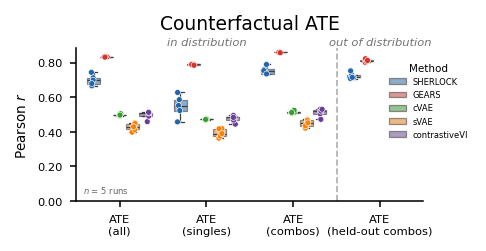

Panel A saved.


In [18]:
# ── Panel A: Counterfactual ATE — in-distribution and OOD ────────────────
METRIC_LABELS = {
    'ate_all':    'ATE\n(all)',
    'ate_single': 'ATE\n(singles)',
    'ate_combo':  'ATE\n(combos)',
    'ate_held':   'ATE\n(held-out combos)',
}

METHOD_ORDER = ['SHERLOCK', 'GEARS', 'cVAE', 'sVAE', 'contrastiveVI']
METHOD_PALETTE = {
    'SHERLOCK':      CLR_SHERLOCK,
    'cVAE':          '#33a02c',
    'sVAE':          '#ff7f00',
    'contrastiveVI': '#6a3d9a',
    'GEARS':         CLR_GEARS,
}

sherlock_ate_df = runs_df[['run'] + list(METRIC_LABELS)].copy()
sherlock_ate_df['method'] = 'SHERLOCK'
gears_ate_df = _gears_run_summ_df[['run'] + list(METRIC_LABELS)].copy()
gears_ate_df['method'] = 'GEARS'
all_ate_df = pd.concat(
    [sherlock_ate_df, gears_ate_df, bench_runs_df[['method', 'run'] + list(METRIC_LABELS)]],
    ignore_index=True,
)

df_long = all_ate_df.melt(
    id_vars=['method', 'run'],
    value_vars=list(METRIC_LABELS),
    var_name='metric', value_name='Pearson r',
)
df_long['Metric'] = pd.Categorical(
    df_long['metric'].map(METRIC_LABELS),
    categories=[METRIC_LABELS[k] for k in METRIC_LABELS],
    ordered=True,
)

TEXT_SCALE_A = -2.  # +/- pt added to all Panel A text uniformly; 0.0 == RC defaults
TEXT_SCALE_B = -1.5

fig_a, ax_a = plt.subplots(figsize=(300/PPI, 150/PPI), constrained_layout=True)

sns.boxplot(
    data=df_long, x='Metric', y='Pearson r', hue='method',
    hue_order=METHOD_ORDER, palette=METHOD_PALETTE,
    width=0.75, linewidth=0.6, fliersize=0, ax=ax_a,
    boxprops=dict(alpha=0.55),
)
sns.stripplot(
    data=df_long, x='Metric', y='Pearson r', hue='method',
    hue_order=METHOD_ORDER, palette=METHOD_PALETTE,
    dodge=True, size=3.5 + TEXT_SCALE_A/3, jitter=0.1,
    linewidth=0.3, edgecolor='white', ax=ax_a, legend=False,
)

ax_a.axvline(2.5, color='0.55', linewidth=0.8, linestyle='--', alpha=0.7)
ax_a.set_ylim(bottom=0)
_ylim = ax_a.get_ylim()
_y_ann = _ylim[1] + 0.07 * (_ylim[1] - _ylim[0])
ax_a.text(1.0, _y_ann, 'in distribution', ha='center', va='top',
          fontsize=5.5 , color='0.45', style='italic')
ax_a.text(3.0, _y_ann, 'out of distribution', ha='center', va='top',
          fontsize=5.5 , color='0.45', style='italic')

ax_a.set_xlabel('')
ax_a.set_ylabel('Pearson $r$', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_B)
ax_a.set_title('Counterfactual ATE', pad=9, fontsize=mpl.rcParams['axes.titlesize'] )
ax_a.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_a.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_B)
ax_a.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_B)
ax_a.text(0.02, 0.04, f'$n$ = {N_RUNS} runs',
          transform=ax_a.transAxes, ha='left', va='bottom',
          fontsize=6 + TEXT_SCALE_A, color='0.4')
ax_a.legend(
    title='Method', frameon=False, loc='upper right',
    bbox_to_anchor=(1.15, 0.95),
    fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE_A,
    title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE_A,
)

fig_a.savefig(OUT_DIR / 'panel_a_ate.svg')
plt.show()
print('Panel A saved.')


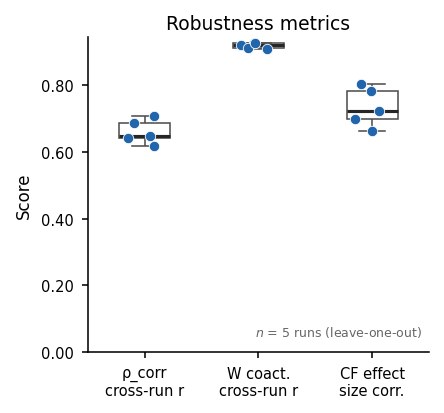

Panel B (robustness) saved.


In [19]:
# ── Panel B: Reproducibility / robustness metrics across N runs ───────────
ROBUST_LABELS = {
    'rho_corr_r':    'ρ_corr\ncross-run r',
    'w_coact_r':     'W coact.\ncross-run r',
    'effect_size_r': 'CF effect\nsize corr.',
}

df_robust = pd.concat([
    pairwise_df.rename(columns={'r': 'Score'})[['metric', 'Score']],
    runs_df[['effect_size_r']].rename(columns={'effect_size_r': 'Score'}).assign(metric='effect_size_r'),
], ignore_index=True)
df_robust['Metric'] = pd.Categorical(
    df_robust['metric'].map(ROBUST_LABELS),
    categories=[ROBUST_LABELS[k] for k in ROBUST_LABELS],
    ordered=True,
)

fig_b2, ax_b2 = plt.subplots(figsize=(3.0, 2.8))

sns.stripplot(
    data=df_robust, x='Metric', y='Score',
    color=CLR_SHERLOCK, size=5, jitter=0.15,
    linewidth=0.4, edgecolor='white', ax=ax_b2,
)
sns.boxplot(
    data=df_robust, x='Metric', y='Score',
    color='white', width=0.45, linewidth=0.75,
    fliersize=0, ax=ax_b2,
    boxprops=dict(edgecolor='0.3'),
    whiskerprops=dict(color='0.3'),
    capprops=dict(color='0.3'),
    medianprops=dict(color='0.15', linewidth=1.5),
)

ax_b2.set_ylim(bottom=0)
ax_b2.set_xlabel('')
ax_b2.set_ylabel('Score')
ax_b2.set_title('Robustness metrics', pad=4)
ax_b2.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_b2.text(0.98, 0.04, f'$n$ = {N_RUNS} runs (leave-one-out)',
           transform=ax_b2.transAxes, ha='right', va='bottom',
           fontsize=6, color='0.4')

plt.tight_layout()
fig_b2.savefig(OUT_DIR / 'panel_b_robustness.svg', bbox_inches='tight')
plt.show()
print('Panel B (robustness) saved.')

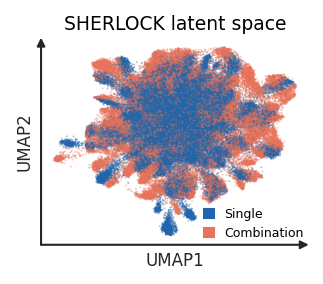

Panel C saved.


In [20]:
# ── Panel C: SHERLOCK latent embedding — singles vs combinations ──────────
_type_pal = {'single': CLR_SHERLOCK, 'combination': '#E8735A'}
_pt        = all_sub.obs['pert_type'].values

fig_c, ax_c = plt.subplots(figsize=(196/PPI, 171/PPI), constrained_layout=True)
ax_c.scatter(
    all_sub.obsm['X_umap'][:, 0], all_sub.obsm['X_umap'][:, 1],
    c=[_type_pal[t] for t in _pt],
    s=0.8, alpha=0.4, linewidths=0, rasterized=True,
)
ax_c.set_xlabel('')
ax_c.set_ylabel('')
ax_c.set_title('SHERLOCK latent space', pad=4)
ax_c.set_xticks([])
ax_c.set_yticks([])
for sp in ax_c.spines.values():
    sp.set_visible(False)
_add_umap_axis_indicator(ax_c, length=1.0)
ax_c.legend(
    handles=[Patch(color=v, label=k.capitalize()) for k, v in _type_pal.items()],
    frameon=False, loc='lower right', handlelength=0.8, borderaxespad=0,
)

fig_c.savefig(OUT_DIR / 'panel_c_umap.svg')
plt.show()
print('Panel C saved.')

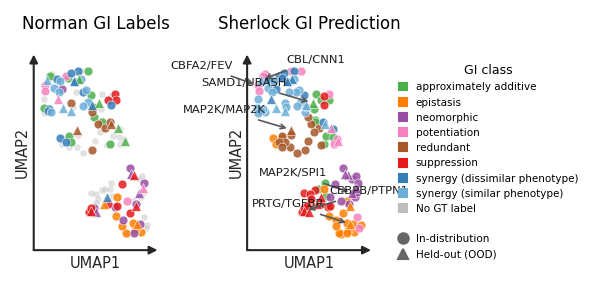

Panel D (synergy UMAP) saved.


In [21]:
# ── Panel D: Synergy UMAP — GT class (left) vs predicted class (right) ──
def _draw_synergy_umap(ax, umap_df, colour_col, title,
                       val_combos=None, arrow_pairs=None, show_unlabelled=False,
                       right_labels=None, show_axis=True, text_scale=0.0, margin=0.1):
    """
    colour_col: column to colour by (gt_gi or predicted_gi).
    show_unlabelled: if True, draw NaN rows as gray (for GT panel only).
    arrow_pairs: {display_label: canonical_idx}
    """
    labelled   = umap_df[umap_df[colour_col].notna()].copy()
    unlabelled = umap_df[umap_df[colour_col].isna()].copy()

    if show_unlabelled and len(unlabelled) > 0:
        ax.scatter(
            unlabelled['UMAP1'], unlabelled['UMAP2'],
            color='0.75', s=10, alpha=0.45, linewidths=0, zorder=1,
        )

    if val_combos is not None:
        in_dist  = labelled[~labelled.index.isin(val_combos)]
        out_dist = labelled[labelled.index.isin(val_combos)]
    else:
        in_dist  = labelled
        out_dist = labelled.iloc[0:0]

    for cls in sorted(labelled[colour_col].unique()):
        color   = PALETTE_GI.get(str(cls), '#888888')
        grp_id  = in_dist[in_dist[colour_col] == cls]
        grp_ood = out_dist[out_dist[colour_col] == cls]
        if len(grp_id) > 0:
            ax.scatter(
                grp_id['UMAP1'], grp_id['UMAP2'],
                color=color, marker='o', s=18, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=2,
            )
        if len(grp_ood) > 0:
            ax.scatter(
                grp_ood['UMAP1'], grp_ood['UMAP2'],
                color=color, marker='^', s=22, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=3,
            )

    if arrow_pairs:
        for display_label, idx in arrow_pairs.items():
            if idx not in umap_df.index:
                continue
            row  = umap_df.loc[idx]
            x, y = float(row['UMAP1']), float(row['UMAP2'])
            _right = right_labels and display_label in right_labels
            ax.annotate(
                display_label,
                xy=(x, y), xytext=(x + 1.5 if _right else x - 1.5, y + 0.8),
                fontsize=6.5 + text_scale, color='0.1',
                ha='left' if _right else 'right', va='bottom',
                arrowprops=dict(
                    arrowstyle='->', color='0.35',
                    lw=0.8, shrinkA=2, shrinkB=2,
                ),
            )

    ax.margins(margin)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title, pad=3, y=1.1, fontsize=mpl.rcParams['axes.titlesize'] + text_scale)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    if show_axis:
        _add_umap_axis_indicator(ax, length=1.0, fontsize=mpl.rcParams['axes.labelsize'] + text_scale)


TEXT_SCALE = - 1.0  # +/- pt added to all Panel D text uniformly; 0.0 == RC defaults

fig_d, axes_d = plt.subplots(1, 2, figsize=(371/PPI, 172/PPI), constrained_layout=True)

_draw_synergy_umap(axes_d[0], syn_umap, 'gt_gi', 'Norman GI Labels',
                   val_combos=val_combos, arrow_pairs=None,
                   show_unlabelled=True, show_axis=True, text_scale=TEXT_SCALE, margin=0.1)
_draw_synergy_umap(axes_d[1], syn_umap, 'predicted_gi', 'Sherlock GI Prediction',
                   val_combos=val_combos, arrow_pairs=_gi_arrows,
                   show_unlabelled=False, show_axis=True, text_scale=TEXT_SCALE, margin=0.1,
                   right_labels={'CBL/CNN1', 'CEBPB/PTPN1'})

# Legend
SHOW_LEGEND = True  # temporarily off to check panel sizing on the 371x172px canvas
class_handles = [Patch(color=PALETTE_GI.get(cls, '#888888'), label=cls) for cls in sorted(PALETTE_GI)]
extra_handles = [
    Patch(color='0.75', label='No GT label'),
    Patch(color='none', label=''),
    Line2D([0], [0], marker='o', color='0.4', linestyle='None', ms=5, label='In-distribution'),
    Line2D([0], [0], marker='^', color='0.4', linestyle='None', ms=5, label='Held-out (OOD)'),
]
if SHOW_LEGEND:
    axes_d[1].legend(
        handles=class_handles + extra_handles,
        title='GI class', frameon=False,
        fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE,
        title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE,
        bbox_to_anchor=(1.15, 1), loc='upper left',
        handlelength=0.8, handleheight=0.8,
    )

fig_d.savefig(OUT_DIR / 'panel_d_synergy_umap.svg')
plt.show()
print('Panel D (synergy UMAP) saved.')


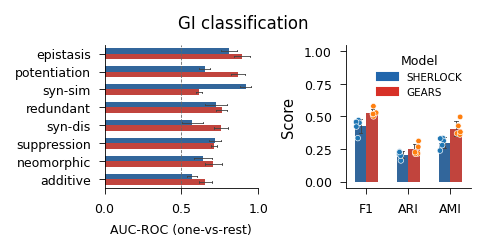

Panel E saved.


In [22]:
# ── Panel E: GI classification — per-class AUC (left) + summary (right) ──
class_order = (
    class_df.groupby('class')['auc_roc']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
bar_pal = {'SHERLOCK': CLR_SHERLOCK, 'GEARS': CLR_GEARS}

TEXT_SCALE_E = -1.0  # +/- pt added to all Panel E text uniformly; 0.0 == RC defaults

fig_e, (ax_e1, ax_e2) = plt.subplots(
    1, 2, figsize=(300/PPI, 150/PPI), constrained_layout=True,
    gridspec_kw={'width_ratios': [2.2, 1.8]},
)

# Left: per-class AUC-ROC
sns.barplot(
    data=class_df_ci.dropna(subset=['auc_roc']),
    y='class', x='auc_roc',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, order=class_order,
    width=0.62, errorbar='sd', capsize=0.15, err_kws={'linewidth': 0.4}, ax=ax_e1, legend=False,
)
ax_e1.axvline(0.5, color='0.4', linewidth=0.4, linestyle='--')
ax_e1.set_xlabel('AUC-ROC (one-vs-rest)', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_E - 1)
ax_e1.set_ylabel('')
_CLASS_LABEL_MAP = {
    'approximately additive':         'additive',
    'synergy (similar phenotype)':    'syn-sim',
    'synergy (dissimilar phenotype)': 'syn-dis',
}
ax_e1.set_yticklabels([_CLASS_LABEL_MAP.get(c, c) for c in class_order])
ax_e1.set_xlim(0, 1)
ax_e1.set_xticks([0, 0.5, 1.0])
ax_e1.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_E)
ax_e1.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_E)
ax_e1.spines['left'].set_linewidth(0.4)
ax_e1.spines['bottom'].set_linewidth(0.4)
ax_e1.tick_params(axis='both', width=0.4)
ax_e1.spines['top'].set_visible(False)
ax_e1.spines['right'].set_visible(False)
h1 = [Patch(color=bar_pal[m], label=m) for m in ['SHERLOCK', 'GEARS']]
l1 = ['SHERLOCK', 'GEARS']

# Right: F1, ARI, AMI with SHERLOCK CIs across runs
sns.barplot(
    data=summ_long_ci, x='Metric', y='score',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, width=0.55, errorbar='sd', capsize=0.15, err_kws={'linewidth': 0.4}, ax=ax_e2,
)
sns.stripplot(
    data=summ_long_ci, x='Metric', y='score',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    dodge=True, size=3 + TEXT_SCALE_E / 3, jitter=0.1,
    linewidth=0.3, edgecolor='white', ax=ax_e2, legend=False,
)
ax_e2.set_xlabel('')
ax_e2.set_ylabel('Score', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_E)
ax_e2.set_ylim(-0.05, 1.05)
ax_e2.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_E)
ax_e2.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_E)
ax_e2.spines['left'].set_linewidth(0.4)
ax_e2.spines['bottom'].set_linewidth(0.4)
ax_e2.tick_params(axis='both', width=0.4)
ax_e2.spines['top'].set_visible(False)
ax_e2.spines['right'].set_visible(False)
ax_e2.get_legend().remove()
ax_e2.legend(h1, l1, title='Model', frameon=False,
             fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE_E,
             title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE_E,
             loc='upper right', bbox_to_anchor=(1, 1))

fig_e.suptitle('GI classification', fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_E)
fig_e.savefig(OUT_DIR / 'panel_e_gi_classification.svg')
plt.show()
print('Panel E saved.')


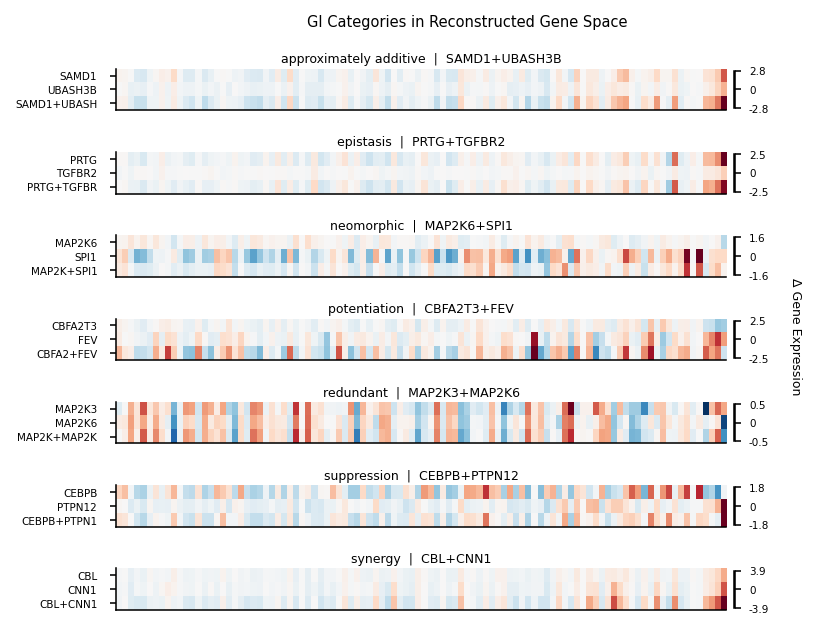

Panel F saved. Arrow pairs: ['CBL/CNN1', 'SAMD1/UBASH', 'PRTG/TGFBR', 'MAP2K/SPI1', 'CBFA2/FEV', 'MAP2K/MAP2K', 'CEBPB/PTPN1']


In [23]:
# ── Panel F: GI Categories in Gene Space ─────────────────────────────────
# One correctly-classified example per GT category (prefer held-out).
# Gene pool: top 100 by variance across all perturbations in treat_effect.
# Also captures _gi_examples for use as panel D arrow annotations.

def _ch(s):
    parts = str(s).split('+', 1)
    return '+'.join(sorted(p.strip() for p in parts)) if len(parts) == 2 else str(s)

_te_f = data.uns['treat_effect'].to_df()
_te_f.index = _te_f.index.map(_ch)

def _eff_f(pert):
    k = _ch(pert)
    return _te_f.loc[k].values if k in _te_f.index else None

# Top-100 highest-variance genes across all perturbations
_hv100 = np.argsort(_te_f.var(axis=0).values)[-100:]

_cats_f = _cats_gi   # defined alongside _gi_examples in the synergy UMAP cell

_nf       = len(_gi_examples)
TEXT_SCALE_F = -2.0  # +/- pt added to all Panel F text uniformly; 0.0 == RC defaults
fig_f, _axes_f_col = plt.subplots(
    _nf, 1, figsize=(600/PPI, 450/PPI), constrained_layout=True,
    gridspec_kw={'hspace': 1.0},
)
_axes_f_flat = np.array(_axes_f_col).flatten()
fig_f.get_layout_engine().set(h_pad=0.2)

for _i, _cat in enumerate(_cats_f):
    _ax = _axes_f_flat[_i]
    if _cat not in _gi_examples:
        _ax.set_visible(False)
        continue

    _row        = _gi_examples[_cat]
    _na, _nb    = str(_row['pert_a']), str(_row['pert_b'])
    _combo      = _ch(f'{_na}+{_nb}')
    _A, _B, _AB = _eff_f(_na), _eff_f(_nb), _eff_f(_combo)

    if _A is None or _B is None or _AB is None:
        _ax.text(0.5, 0.5, f'missing data\n{_combo}', ha='center', va='center',
                 transform=_ax.transAxes, fontsize=7 + TEXT_SCALE_F)
        continue

    _mat  = np.stack([_A[_hv100], _B[_hv100], _AB[_hv100]])
    _vabs = float(np.abs(_mat).max()) or 1.0
    _im   = _ax.imshow(_mat, aspect='auto', cmap='RdBu_r',
                       vmin=-_vabs, vmax=_vabs, interpolation='nearest')
    _cbar = plt.colorbar(_im, ax=_ax, shrink=0.9, pad=0.01)
    _cbar.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_F)
    _cbar.set_ticks([-_vabs, 0, _vabs])
    _cbar.set_ticklabels([f'{-_vabs:.1f}', '0', f'{_vabs:.1f}'])

    _ax.set_yticks([0, 1, 2])
    _ax.set_yticklabels([_na, _nb, f'{_na[:5]}+{_nb[:5]}'], fontsize=7 + TEXT_SCALE_F)
    _ax.tick_params(axis='y', pad=6)
    _ax.set_xticks([])
    _ax.set_title(f'{_cat}  |  {_combo}', pad=3,
                   fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_F - 1)



fig_f.text(0.85, 0.5, 'Δ Gene Expression', rotation=270, va='center', ha='center',
           fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_F)
fig_f.suptitle('GI Categories in Reconstructed Gene Space',
                fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_F)
fig_f.savefig(OUT_DIR / 'panel_f_gi_heatmap.svg')
plt.show()

# Build arrow dict for panel D
_gi_arrows = {}
for _cat, _row in _gi_examples.items():
    _na2, _nb2 = str(_row['pert_a']), str(_row['pert_b'])
    _cidx = _ch(f'{_na2}+{_nb2}')
    if _cidx in syn_umap.index:
        _lbl = f'{_na2[:5]}/{_nb2[:5]}'
        _gi_arrows[_lbl] = _cidx

print(f'Panel F saved. Arrow pairs: {list(_gi_arrows.keys())}')


In [24]:
# ── Summary statistics ────────────────────────────────────────────────────
print('=== ATE across runs ===')
print(runs_df[['run', 'ate_all', 'ate_single', 'ate_combo', 'ate_held']].to_string(index=False))

print(f'\nMean ± SD:')
for col in ['ate_all', 'ate_single', 'ate_combo', 'ate_held']:
    print(f"  {col:15s}  {runs_df[col].mean():.4f} ± {runs_df[col].std():.4f}")

print('\n=== GI classification summary (SHERLOCK vs GEARS) ===')
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'ami']].to_string(index=False))

=== ATE across runs ===
 run  ate_all  ate_single  ate_combo  ate_held
   1 0.712546    0.585499   0.761517  0.728717
   2 0.665266    0.456864   0.736384  0.707254
   3 0.743466    0.627053   0.789259  0.752105
   4 0.698181    0.551273   0.753197  0.714110
   5 0.678420    0.522366   0.734154  0.714480

Mean ± SD:
  ate_all          0.6996 ± 0.0305
  ate_single       0.5486 ± 0.0645
  ate_combo        0.7549 ± 0.0224
  ate_held         0.7233 ± 0.0179

=== GI classification summary (SHERLOCK vs GEARS) ===
   model  f1_weighted  silhouette      ari      ami
SHERLOCK     0.450620   -0.060369 0.210131 0.312392
   GEARS     0.518024    0.044261 0.266228 0.427166


Overall silhouette: -0.0545
GT samples used: 86 in 8 classes

                                  mean   n    std
class                                            
potentiation                   -0.3675   6 0.2613
neomorphic                     -0.2684  12 0.1752
synergy (dissimilar phenotype) -0.1746  13 0.1044
approximately additive         -0.0779  15 0.0958
redundant                      -0.0629   8 0.1725
suppression                     0.0381  12 0.2036
synergy (similar phenotype)     0.1730  11 0.0782
epistasis                       0.2571   9 0.1720


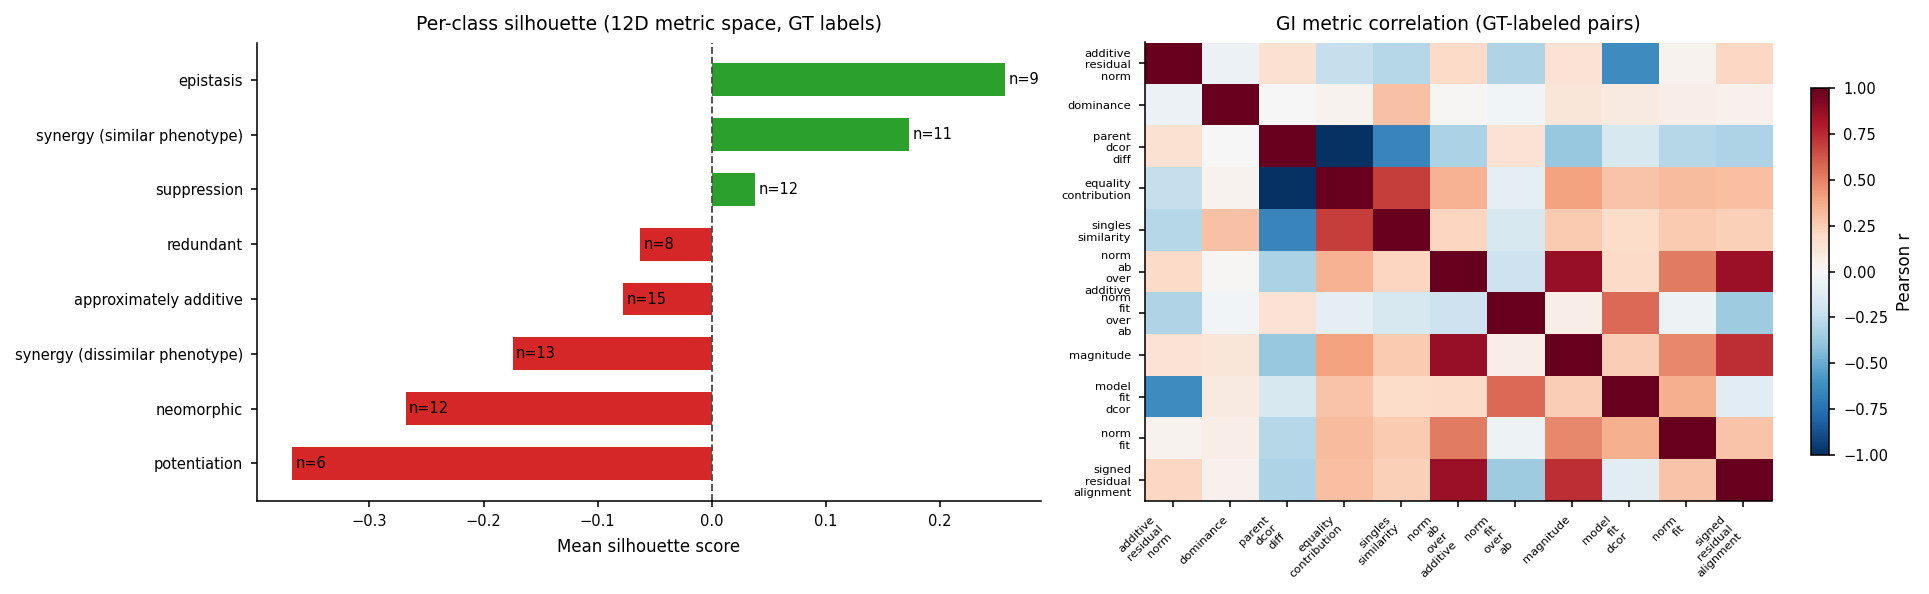

In [25]:
# ── Silhouette investigation ──────────────────────────────────────────────
# Silhouette is computed in the 12D GI metric space (StandardScaled).
# Low overall score can stem from: (1) overlapping classes in metric space,
# (2) small classes making estimation unreliable, (3) correlated metrics
# reducing effective dimensionality without removing redundancy.

from sklearn.metrics import silhouette_samples

# Replicate the _cluster_metrics computation for SHERLOCK
_both  = syn_umap[syn_umap['gt_gi'].notna()].copy()
_avail = [c for c in GI_METRICS if c in _both.columns]
_X_raw = _both[_avail].values.astype(float)
_fin   = np.all(np.isfinite(_X_raw), axis=1)
_both  = _both[_fin].copy()
_X_s   = StandardScaler().fit_transform(_X_raw[_fin])
_y_gt  = _both['gt_gi'].values.astype(str)

# Per-sample silhouette → aggregate per class
_samp_sil = silhouette_samples(_X_s, _y_gt)
_sil_df   = pd.DataFrame({'class': _y_gt, 'silhouette': _samp_sil})
_per_cls  = (_sil_df.groupby('class')['silhouette']
               .agg(mean='mean', n='count', std='std')
               .sort_values('mean'))

print(f"Overall silhouette: {_samp_sil.mean():.4f}")
print(f"GT samples used: {len(_y_gt)} in {len(np.unique(_y_gt))} classes\n")
print(_per_cls.to_string(float_format='{:.4f}'.format))

# Metric pairwise correlation (may reveal redundancy inflating some distances)
_corr = pd.DataFrame(_X_raw[_fin], columns=_avail).corr()

fig_inv, (ax_i1, ax_i2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: per-class mean silhouette
colors = ['#d62728' if v < 0 else '#2ca02c' for v in _per_cls['mean']]
ax_i1.barh(_per_cls.index, _per_cls['mean'], color=colors, height=0.6)
ax_i1.axvline(0, color='0.3', linewidth=0.9, linestyle='--')
for i, (cls, row) in enumerate(_per_cls.iterrows()):
    ax_i1.text(row['mean'] + 0.003, i, f"n={int(row['n'])}", va='center', fontsize=7)
ax_i1.set_xlabel('Mean silhouette score')
ax_i1.set_title('Per-class silhouette (12D metric space, GT labels)')
ax_i1.spines['top'].set_visible(False); ax_i1.spines['right'].set_visible(False)

# Right: metric correlation heatmap — high off-diagonal correlations explain
# why the effective dimensionality is lower than 12
short = [m.replace('_', '\n') for m in _avail]
im = ax_i2.imshow(_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax_i2.set_xticks(range(len(_avail))); ax_i2.set_xticklabels(short, fontsize=5.5, rotation=45, ha='right')
ax_i2.set_yticks(range(len(_avail))); ax_i2.set_yticklabels(short, fontsize=5.5)
plt.colorbar(im, ax=ax_i2, shrink=0.8, label='Pearson r')
ax_i2.set_title('GI metric correlation (GT-labeled pairs)')

plt.tight_layout()
plt.show()
